# PProd analysis 

In [11]:
import pandas as pd
import glob
import os

In [61]:
def merge_data_files(fin):
    dflist = []
    for f in fin:
        df = pd.read_csv(f, delimiter='\s+', skiprows=1, header=None)
        df.columns = ['ij', 'pla', 'x', 'y', 'z', 'txx', 'tyy', 'tzz', 'wee']
        print(f' -- procesed file : {f=} : {df.shape[0]} particles read')
        dflist.append(df)
    df = pd.concat(dflist)
    df[['px','py','pz']] = df.apply(lambda x: (x.pla*x.txx, x.pla*x.tyy, x.pla*x.tzz), axis=1, result_type='expand')
    return df

In [3]:
!pwd

/Users/iliasefthymiopoulos/Work/esslenustorm/myanal


In [62]:
fin = glob.glob(f'./pprod_at_target/ESS*pprod.dat')
_aux = merge_data_files(fin)
_aux = _aux[_aux.tzz >= 0] # select forward particles



 -- procesed file : f='./pprod_at_target/ESS014_target_pprod.dat' : 29393 particles read
 -- procesed file : f='./pprod_at_target/ESS004_target_pprod.dat' : 29311 particles read
 -- procesed file : f='./pprod_at_target/ESS010_target_pprod.dat' : 29266 particles read
 -- procesed file : f='./pprod_at_target/ESS015_target_pprod.dat' : 29186 particles read
 -- procesed file : f='./pprod_at_target/ESS020_target_pprod.dat' : 29336 particles read
 -- procesed file : f='./pprod_at_target/ESS001_target_pprod.dat' : 29391 particles read
 -- procesed file : f='./pprod_at_target/ESS005_target_pprod.dat' : 29294 particles read
 -- procesed file : f='./pprod_at_target/ESS011_target_pprod.dat' : 29287 particles read
 -- procesed file : f='./pprod_at_target/ESS002_target_pprod.dat' : 29380 particles read
 -- procesed file : f='./pprod_at_target/ESS016_target_pprod.dat' : 29226 particles read
 -- procesed file : f='./pprod_at_target/ESS009_target_pprod.dat' : 29260 particles read
 -- procesed file : f

In [71]:
_aux.ij.unique()

array([13, 14, 15])

In [69]:
_protons = _aux[_aux.ij.isin([1, 2])]
_pions = _aux[_aux.ij.isin([13, 14])]
_muons = _aux[_aux.ij.isin([10, 11])]
print(_protons.shape[0], _pions.shape[0], _muons.shape[0])

0 460659 0


<AxesSubplot:>

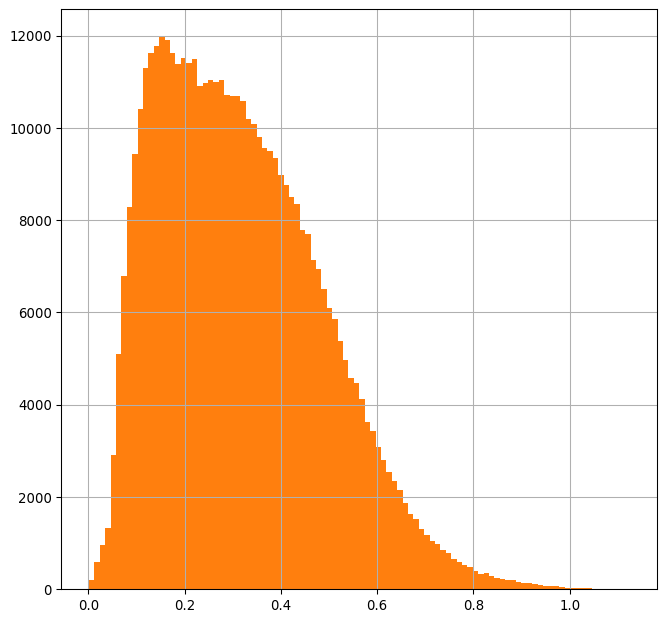

In [68]:

_protons.pla.hist(bins=100)
_pions.pla.hist(bins=100)
_muons.pla.hist(bins=100)

In [34]:
pd.read_fwf?

Signature:
pd.read_fwf(
    filepath_or_buffer: 'FilePathOrBuffer',
    colspecs='infer',
    widths=None,
    infer_nrows=100,
    **kwds,
)
Docstring:
Read a table of fixed-width formatted lines into DataFrame.

Also supports optionally iterating or breaking of the file
into chunks.

Additional help can be found in the `online docs for IO Tools
<https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html>`_.

Parameters
----------
filepath_or_buffer : str, path object or file-like object
    Any valid string path is acceptable. The string could be a URL. Valid
    URL schemes include http, ftp, s3, and file. For file URLs, a host is
    expected. A local file could be:
    ``file://localhost/path/to/table.csv``.

    If you want to pass in a path object, pandas accepts any
    ``os.PathLike``.

    By file-like object, we refer to objects with a ``read()`` method,
    such as a file handle (e.g. via builtin ``open`` function)
    or ``StringIO``.
colspecs : list of tuple (int, in

In [27]:
import re
txt = open(fin[0])
preparse = re.findall('\n', txt)
parsed = [t[0].split(' ') for t in preparse]
pd.DataFrame(parsed)

TypeError: expected string or bytes-like object